<a href="https://colab.research.google.com/github/lcuenca1/Data201/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicting Mortality Rates in Montgomery County**
  
Data 201  
Leyla Cuenca

---

## **i. Introduction**

This project uses the Population Health Measures: Age- Adjusted Mortality Rate dataset from Montgomery County Health and Human Services. This dataset contains mortality rate information for different demographic groups based on factors such as race, gender, cause of death, and others. This dataset contains over 12 thousand observations and 9 variables. Each row represents a demographic group and its corresponding mortality rate per 100,000 populations.
  
The goal of this project is to predict the Age-adjusted Mortality Rate per 100 populations  using Decision Tree, Random Forest, and Gradient Boosting regression models. The project compares whether these models can outperform a single decision tree in prediction accuracy.  
  
This topic is relevant because mortality rates can reveal health differences across demographic groups and causes of death. Understanding this patterns can help identify any imbalance and support public health decision making in Maryland and Montgomery County.  
  
One possible limitation from this dataset is that some rows contain missing values, most likely due to small population sizeor suppressed statistics. In addition, the dataset is aggregated rather than individual data, which may limit how precisely the models capture real world changes.  

Source: https://data.montgomerycountymd.gov/Health-and-Human-Services/Population-Health-Measures-Age-Adjusted-Mortality-/j55i-sqj8/about_data    

### **II. Dataset and Preparation**  
  

This section loads the dataset , explore its structure , handles missing values, and prepares the data for machine learnings model.

In [1]:
# Importing libraries

import pandas as pd
import numpy as np

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
# Importing Dataset

from google.colab import files
uploaded = files.upload()

Saving Population_Health_Measures__Age-Adjusted_Mortality_Rates_20260513.csv to Population_Health_Measures__Age-Adjusted_Mortality_Rates_20260513.csv


In [3]:
import pandas as pd

df = pd.read_csv("Population_Health_Measures__Age-Adjusted_Mortality_Rates_20260513.csv")
df.head()

,Unique ID,3-Year Period,Cause of Death,Race,Hispanic or Latino Origin,Gender,"Age-Adjusted Rate per 100,000 Population",Lower 95% Confidence Interval,Upper 95% Confidence Interval
0,A2010201200000,2010-2012,All causes of mortality,Total,Total,Total,517.3,509.6,525.1
1,A2010201200001,2010-2012,All causes of mortality,Total,Total,Male,609.3,596.2,622.5
2,A2010201200002,2010-2012,All causes of mortality,Total,Total,Female,450.2,440.8,459.6
3,A2010201200010,2010-2012,All causes of mortality,Total,Not Hispanic,Total,531.8,523.6,540.0
4,A2010201200011,2010-2012,All causes of mortality,Total,Not Hispanic,Male,623.4,609.5,637.2


This dataset contains 12,150 rows, and 9 colums which represent variables that will be described below on the variables table.

In [4]:
df.shape

(12150, 9)

**Variables Description**

| Variable | Type | Description |
|----------|------|-------------|
| Unique ID | Categorical (ID) | Unique identifier for each record |
| 3-Year Period | Categorical | Time period (e.g., 2010–2012) |
| Cause of Death | Categorical | Medical cause of mortality |
| Race | Categorical | Race group (e.g., White, Black, Total) |
| Hispanic or Latino Origin | Categorical | Ethnicity classification |
| Gender | Categorical | Gender category (Male, Female, Total) |
| Age-Adjusted Rate per 100,000 Population | Numeric (Target) | Death rate used as prediction target |
| Lower 95% Confidence Interval | Numeric | Lower bound of statistical confidence |
| Upper 95% Confidence Interval | Numeric | Upper bound of statistical confidence |

**Handling Missing Values**

In [5]:
# Checking how many missing values are present in the dataset
df.isnull().sum()

,0
Unique ID,0
3-Year Period,0
Cause of Death,0
Race,0
Hispanic or Latino Origin,0
Gender,0
"Age-Adjusted Rate per 100,000 Population",2910
Lower 95% Confidence Interval,2906
Upper 95% Confidence Interval,2910


In [6]:
# Dropping missing values
df = df.dropna(subset=["Age-Adjusted Rate per 100,000 Population"])

the dataset contains missing values primarily in the age-adjusted mortality rate and confidence interval columns. Since the mortality rate is the target variable for prediction, rows with missing values were removed.

**Encoding**

In [7]:
df_encoded = pd.get_dummies(df, drop_first=True)

Categorical variables such as gender, race, and cause of deathwere converted into numerical format using one encoding. This transformation allows machin learning models to interpret categorical information as binary features.

**Train/ Test Split**

In [8]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("Age-Adjusted Rate per 100,000 Population", axis=1)
y = df_encoded["Age-Adjusted Rate per 100,000 Population"]

# Train/test split code
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Sizes
print(X_train.shape)
print(X_test.shape)

(7392, 9306)
(1848, 9306)


The dataset was split into training and testing sets using an 80/20 ratio. The training set contains 7,392 observations, while the testing set contains 1848 observations. After encoding categorical variables, the dataset expanded to 9306 features. This increase is expected because each category level is converted into a separate binary variable.

## **III. Exploratory Data Analysis**

**a) Mortality Rate Distribution**

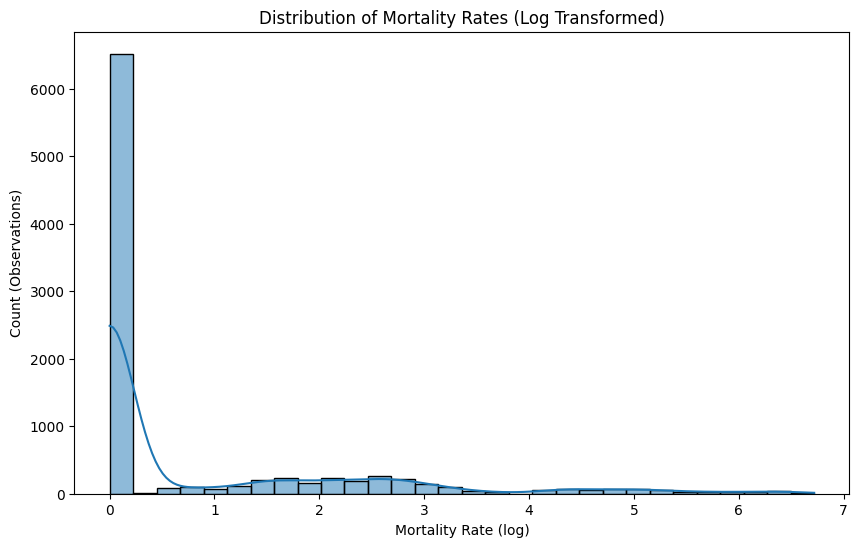

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10,6))
sns.histplot(
    np.log1p(df["Age-Adjusted Rate per 100,000 Population"]),
    bins=30, kde=True)

plt.title("Distribution of Mortality Rates (Log Transformed)")
plt.xlabel("Mortality Rate (log)")
plt.ylabel("Count (Observations)")
plt.show()

This plot shows that the distribution of age-adjusted mortalityrates is highly right skewed. Most concentrations are concentrated at lower values, while a small number of cases show significantly higher rates, forming a long right tail. This probably because mortality outcomes vary widely depending on demographic and health factors. To improve the visualization and interpretation of it, a log transformation was necessary

**b) Mortality Rate by cause of death**

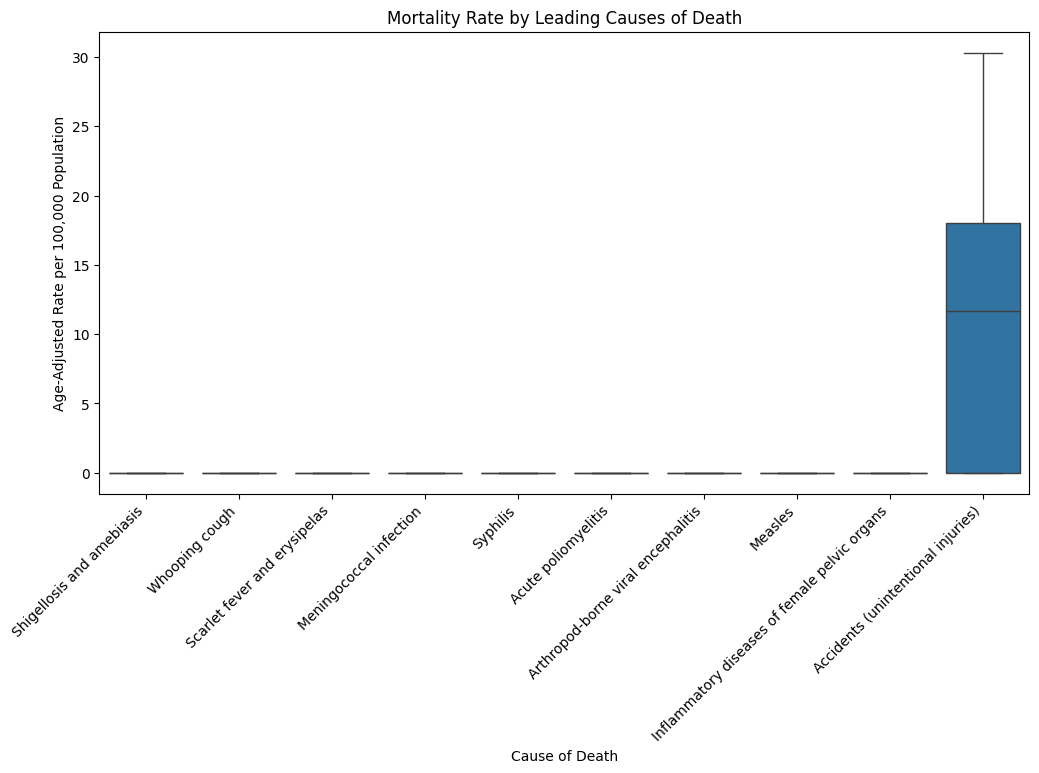

In [14]:
import matplotlib.pyplot as plt

top_causes = df["Cause of Death"].value_counts().head(10).index
filtered_df = df[df["Cause of Death"].isin(top_causes)]

plt.figure(figsize=(12,6))
sns.boxplot(data=filtered_df, x="Cause of Death",
            y="Age-Adjusted Rate per 100,000 Population")

plt.xticks(rotation=45, ha="right")
plt.title("Mortality Rate by Leading Causes of Death")
plt.show()

The distribution of causes of death is highly imbalanced, with the largest proportion of records concentrated in the "Accidents/ Unintentional injuries" category. Other causes in Montgomery County appears to be less frequent. This indicates that certain categories dominate the data. This imbalance is important to highlight when interpreting pattern in mortality rates across different causes.

**c) Gender Comparison**

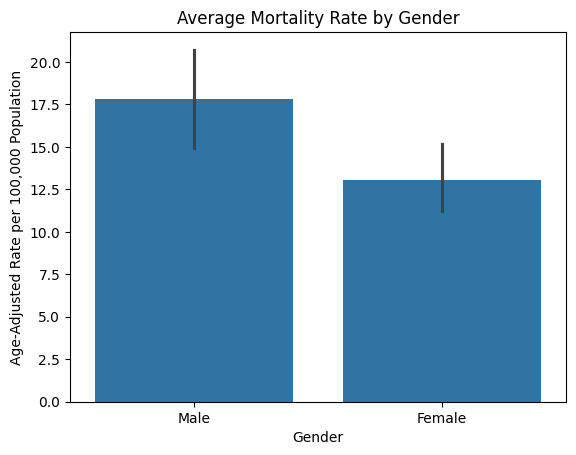

In [15]:
gender_df = df[df["Gender"] != "Total"]

sns.barplot(
    data=gender_df, x="Gender",
    y="Age-Adjusted Rate per 100,000 Population",
    estimator="mean")
plt.title("Average Mortality Rate by Gender")
plt.show()

The visualization compares average age-adjusted mortality rates between male and females . The results shows that males have a higher average mortality rate compared to females. This pattern is consistant with public health researchwhere males often experience higher mortality rates, but more likely as consequence of other causes.

### **IV. Decision Tree Analysis**

In this section, a decision tree model will be use to predict age-adjusted mortality rates. The goal is to understand how different demographic and health related features influence mortality and to interpret how the model makes predictions.

* First Model

In [16]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

tree1 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree1.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3, random_state=42)

In [17]:
y_pred1 = tree1.predict(X_test)

print("Depth 3 Model")
print("MSE:", mean_squared_error(y_test, y_pred1))
print("R2:", r2_score(y_test, y_pred1))

Depth 3 Model
MSE: 80.3571980916722
R2: 0.9854351564620626


This Decision Tree model with depth = 3 performs very well, achieving a R squared of 0.985. This means that the model explains most of the variation in mortality rates. The relatively low error (MSE) suggest strong predictive performance while keeping a simple structure,

* Second Model

In [18]:
tree2 = DecisionTreeRegressor(max_depth=10, random_state=42)
tree2.fit(X_train, y_train)

y_pred2 = tree2.predict(X_test)

print("Depth 10 Model")
print("MSE:", mean_squared_error(y_test, y_pred2))
print("R2:", r2_score(y_test, y_pred2))

Depth 10 Model
MSE: 4.159190902718962
R2: 0.9992461414013788


The deeper decision Tree (Depth = 10) significantly improves performance, reducing a lot the MSE and increasing the R squared value to nearly 1.0. While this is very accurate prediction, such a large improvement compare to the simpler model raises concerns about overfitting. The model may be capturing very specific patterns in the training data that do not generalize well to new unseen data, it probably memorizes the training data.

* Visualization of Smal Tree (Depth = 3)

In [19]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

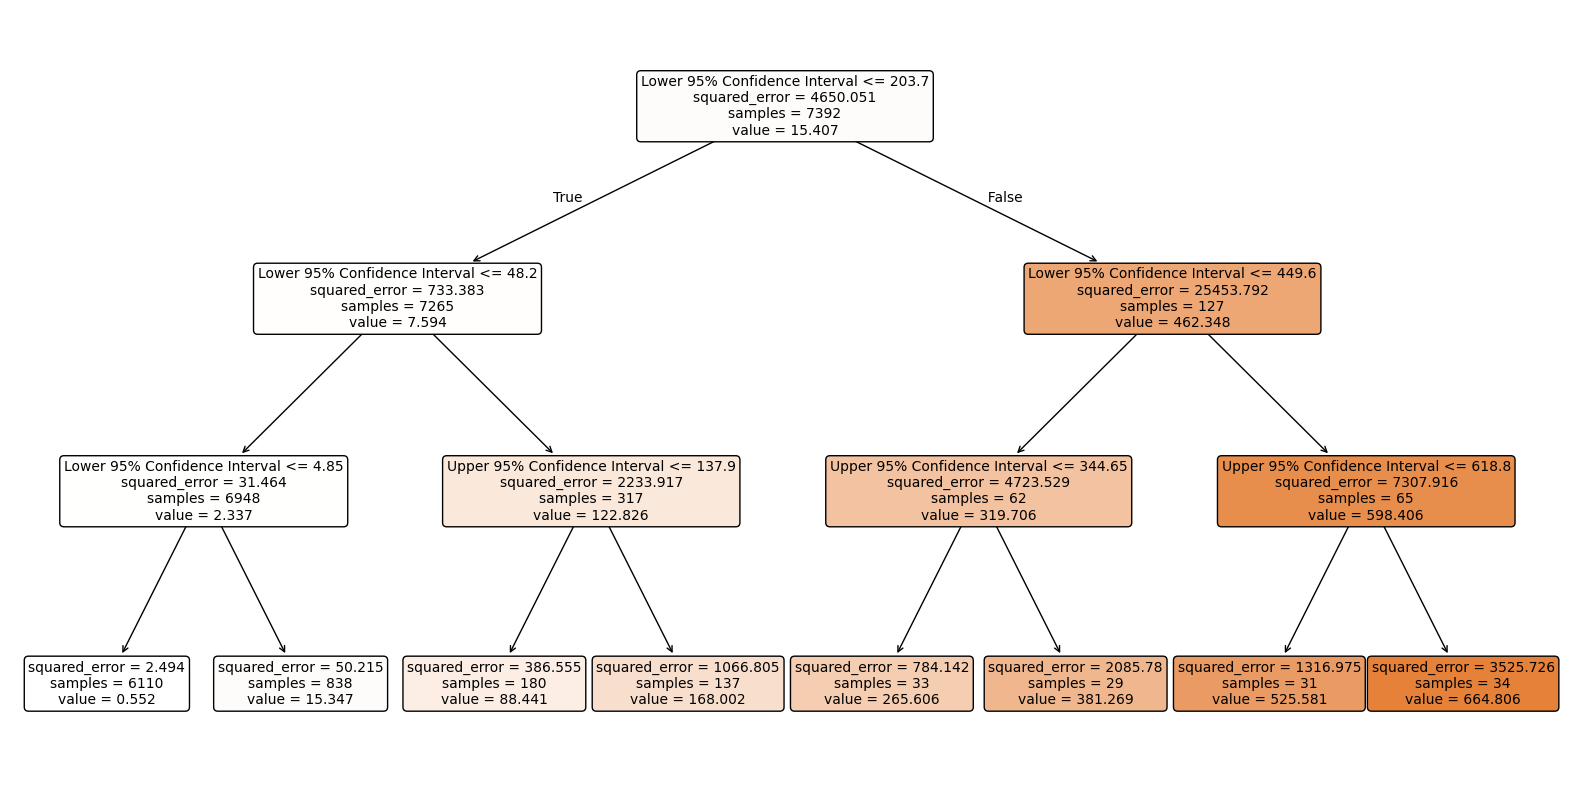

In [20]:
plt.figure(figsize=(20,10))

plot_tree( tree1, feature_names=X_train.columns,
        filled=True, rounded=True, fontsize=10)

plt.show()

The decision tree visualization shows how the model predicts mortality rates by asking a series of simple yes/no questions about the data. The tree begins with the root node, which uses the Lower 95% Confidence Interval as the first and most important split. This initial decision separates observations into lower and higher mortality ranges, showing that this variable has a strong influence on the predictions.

As the tree continues, additional splits divide the data into more specific groups using numerical thresholds. These decisions help the model refine its predictions and separate observations with similar mortality patterns. At the end of each branch, the leaf nodes display the final predicted mortality rate.

One example prediction path occurs when the Lower 95% Confidence Interval falls below a certain threshold, leading the model toward branches associated with lower predicted mortality rates. Higher values move the model in the opposite direction, resulting in higher mortality predictions.
Overall, the decision tree demonstrates how the model uses numerical conditions from the dataset to make structured predictions step by step.

## **V. Esemble Models**

In this section, esemble learning models are used to improve prediction performance by combining multiple decision trees. A Random Forest Regressor and a Gradient Boosting Regressor are trained and compared with the single Decission Tree model. The goal is to evaluate whether ensemble methods produce more accurate and reliable mortality rate predictions.

**a) Random Forest Model**

In [21]:
rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("MSE:", rf_mse)
print("R2:", rf_r2)

Random Forest Results
MSE: 0.7663354908008682
R2: 0.9998611007254341


**b) Gradient Boosting Model**

In [22]:
gb_model = GradientBoostingRegressor(random_state=42)

gb_model.fit(X_train, y_train)
gb_predictions = gb_model.predict(X_test)

gb_mse = mean_squared_error(y_test, gb_predictions)
gb_r2 = r2_score(y_test, gb_predictions)

print("Gradient Boosting Results")
print("MSE:", gb_mse)
print("R2:", gb_r2)

Gradient Boosting Results
MSE: 2.191886650877482
R2: 0.9996027177791029


The esemble models improved prediction performance compared to the single decision tree models. Both Random Forest and Gradient Boosting achieved lower MSE values and higher R square, indicating more accurate predictions. Among the asemble methods, Random Forest produced the best overall performance with the lowest prediction error. These models are combining the predictions of many trees instead of relying on just one structure.  
  
Although the essemble models were more accurate, the single decision tree was easier to interpret and explain visually. The decision tree clearly showed the sequence of decision used to make predictions, while esemble models are more complex because they combine many trees together.  
At the end, it can be suggested that many trees working together can outperform a single decision tree for prediction mortality rates.


## **VI. Model Evaluation**

Here, the performance of all models will be evaluated through a comparison table, and a visualization of Actual vs Predicted using the best model, in this case the Random Forest model.

In [23]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Decision Tree (Depth 3)", "Decision Tree (Depth 10)",
              "Random Forest", "Gradient Boosting"],
    "MSE": [80.357, 4.159, 0.766, 2.192],
    "R2": [0.9854, 0.9992, 0.99986, 0.99960]})
comparison

,Model,MSE,R2
0,Decision Tree (Depth 3),80.357,0.98540
1,Decision Tree (Depth 10),4.159,0.99920
2,Random Forest,0.766,0.99986
3,Gradient Boosting,2.192,0.99960


* Actual vs Predicted Scatterplot

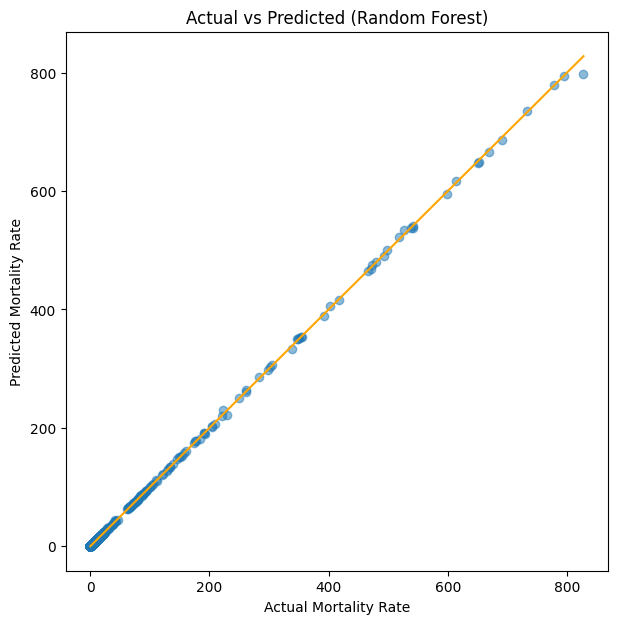

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.scatter(y_test, rf_predictions, alpha=0.5)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="orange")

plt.xlabel("Actual Mortality Rate")
plt.ylabel("Predicted Mortality Rate")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

The evaluation results show that mortality rates in this dataset are highly predictable using demographic and health related variables. All models achieved strong performance, with ensemble methods such as Random Forest and Gradient Boosting providing the most accurate predictions.
The high R² values indicate that most of the variation in age-adjusted mortality rates is explained by the available features in the dataset. This suggests that mortality patterns are strongly structured and influenced by the variables included in the model.

The Actual vs Predicted plot confirms this result, as most predictions closely follow the ideal diagonal line. Small prediction errors mainly occur at higher mortality values, indicating that extreme cases are slightly more difficult for the model to capture accurately.

## **VI. Feature Importance**

Using the Random Forest model for this part is the best option since it was the strongest of all, and will show which variable influenced the most to predict mortality.

In [25]:
importances = rf_model.feature_importances_
feature_names = X_train.columns

feat_df = pd.DataFrame({ "Feature": feature_names, "Importance": importances})
feat_df = feat_df.sort_values(by="Importance", ascending=False)

feat_df.head(10)

,Feature,Importance
0,Lower 95% Confidence Interval,0.774145
1,Upper 95% Confidence Interval,0.225357
9304,Gender_Male,0.000141
9305,Gender_Total,0.000036
28,Unique ID_A2006200800310,0.000030
1907,Unique ID_A2007200900211,0.000030
7468,Unique ID_A2010201200300,0.000021
9298,Race_Asian/Pacific Islander,0.000017
9243,3-Year Period_2009-2011,0.000016
9247,Cause of Death_All causes of mortality,0.000015


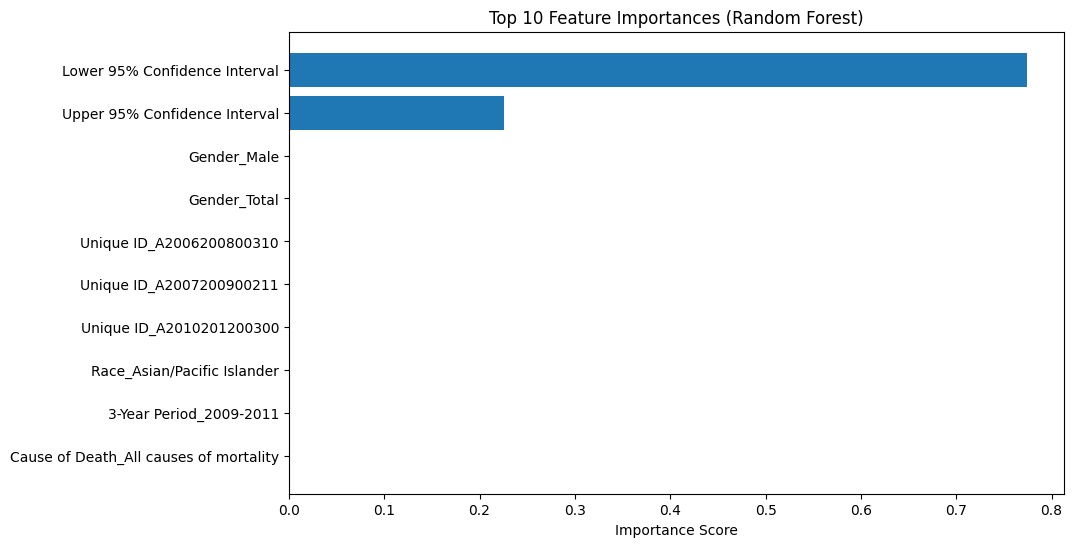

In [26]:
plt.figure(figsize=(10,6))

plt.barh(feat_df["Feature"].head(10)[::-1],
         feat_df["Importance"].head(10)[::-1])

plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")

plt.show()

In [27]:
# Top 3 features
feat_df.head(3)

,Feature,Importance
0,Lower 95% Confidence Interval,0.774145
1,Upper 95% Confidence Interval,0.225357
9304,Gender_Male,0.000141


The feature importance results show that the model relies mostly on the Lower and Upper 95% Confidence Interval variables when predicting age-adjusted mortality rates. These two variables account for nearly all of the predictive power, while all other features contribute very little.

This happens because confidence intervals are closely related to the mortality rate itself, meaning the model is using variables that already contain strong statistical information about the target. As a result, demographic variables such as gender, race, and cause of death have minimal impact on the model’s predictions.

Additionally, the presence of Unique ID variables with near-zero importance indicates that these identifiers do not provide meaningful predictive information and are only present due to data encoding.
It is important to note that feature importance reflects how useful a variable is for prediction, not whether it causes changes in mortality rates.

## **VIII. Final Reflection**

Among all the models tested, the Random Forest Regressor performed the best overall. It achieved the lowest error and the highest R square score, indicating that it provided the most accurate predictions of age-adjusted mortality rates. The Gradient Boosting model also performed very well, with results very close to Random Forest, while both decision tree models were slightly less accurate, especially the simpler tree with lower depth.

In terms of interpretability, the single decision tree was the easiest model to understand. Its step by step structure made it clear how individual features and thresholds were used to reach predictions. In contrast, ensemble models such as Random Forest and Gradient Boosting are more complex because they combine many trees, making their internal decision process harder to follow.

If this model were applied in a real-world setting, the choice would depend on the goal. For maximum accuracy and reliability, Random Forest would be the best option due to its strong predictive performance and stability. However, if transparency and interpretability were more important (for example, in public health reporting), a simpler decision tree might be preferred despite lower accuracy.

Overall, this project demonstrates the trade off between interpretability and performance: simpler models are easier to explain, while ensemble models provide significantly better predictive power for complex datasets like mortality rates.